 # Modeling — King County House Prices
 > Progressive model training: simple → complex, with "why not enough?" at each level.

 **Model Progression:**

 | Level | Model | What It Teaches |
 |-------|-------|-----------------|
 | 1 | Linear Regression | Baseline, assumptions, residuals |
 | 2 | Ridge / Lasso | Regularization, feature importance via coefficients |
 | 3 | Decision Tree | Non-linearity, overfitting, interpretability |
 | 4 | Random Forest | Ensemble, variance reduction, feature importance |
 | 5 | Gradient Boosting | Boosting vs bagging, best tabular performance |
 | 6 | Comparison | Side-by-side metrics, model selection |

 **Metrics used:**
 - RMSE (log scale) — optimization metric
 - MAE ($) — interpretable error in dollars
 - R² — variance explained
 - MAPE (%) — percentage error for business context

 ## 0. Setup & Load

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f"Train: {X_train.shape[0]:,} rows x {X_train.shape[1]} features")
print(f"Test:  {X_test.shape[0]:,} rows x {X_test.shape[1]} features")
print(f"\nFeatures: {list(X_train.columns)}")

Train: 17,290 rows x 16 features
Test:  4,323 rows x 16 features

Features: ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_basement', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'house_age', 'has_renovation']


 ### Helper: evaluate model
 Since target is log-transformed, we convert back to dollars for interpretable metrics.

In [ ]:
results = []


def evaluate(model, name):
    """Evaluate model, store results, print summary."""
    y_pred_log = model.predict(X_test)
    y_pred_train_log = model.predict(X_train)

    # Log-scale metrics
    rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
    rmse_train_log = np.sqrt(mean_squared_error(y_train, y_pred_train_log))

    # Convert back to dollars for interpretable metrics
    y_pred_dollars = np.expm1(y_pred_log)
    y_actual_dollars = np.expm1(y_test)

    mae_dollars = mean_absolute_error(y_actual_dollars, y_pred_dollars)
    r2 = r2_score(y_test, y_pred_log)

    # MAPE — clip predictions to avoid division issues
    mape = np.mean(np.abs(y_actual_dollars - y_pred_dollars) / y_actual_dollars) * 100

    result = {
        'Model': name,
        'RMSE (log)': rmse_log,
        'Train RMSE': rmse_train_log,
        'MAE ($)': mae_dollars,
        'R²': r2,
        'MAPE (%)': mape,
    }
    results.append(result)

    print(f"\n{'=' * 50}")
    print(f"  {name}")
    print(f"{'=' * 50}")
    print(f"  RMSE (log):   {rmse_log:.4f}  (train: {rmse_train_log:.4f})")
    print(f"  MAE:          ${mae_dollars:,.0f}")
    print(f"  R²:           {r2:.4f}")
    print(f"  MAPE:         {mape:.1f}%")
    if rmse_train_log < rmse_log * 0.8:
        print(f"  ⚠ Possible overfitting (train RMSE much lower than test)")

    return y_pred_log

 ---
 ## Level 1: Linear Regression
 **Concept:** Fit a straight line (hyperplane) through the data.
 Assumes linear relationship between each feature and target.

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = evaluate(lr, 'Linear Regression')


  Linear Regression
  RMSE (log):   0.2573  (train: 0.2529)
  MAE:          $118,071
  R²:           0.7677
  MAPE:         20.3%


 ### Linear Regression — Coefficients
 Shows which features the model considers most important (and direction).

In [ ]:
coefs = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print(coefs.to_string(index=False))

       Feature   Coefficient
           lat  1.356778e+00
    waterfront  3.801659e-01
         grade  1.575807e-01
     bathrooms  7.517417e-02
has_renovation  7.395498e-02
        floors  6.870742e-02
     condition  6.570737e-02
          view  5.836602e-02
          long -3.018028e-02
      bedrooms -1.124075e-02
     house_age  3.348989e-03
   sqft_living  1.369813e-04
 sqft_living15  1.042409e-04
 sqft_basement  1.308962e-05
      sqft_lot  3.907524e-07
    sqft_lot15 -1.912089e-07


 ### Why not enough?
 Linear regression assumes each feature has a constant, additive effect on price.
 Reality: a waterfront view matters more for large houses than small ones (interactions).
 Grade 13 isn't just "grade 7 + 6 more points" — the effect is non-linear.
 -> Let's try regularization first, then move to models that capture non-linearity.

 ---
 ## Level 2: Ridge & Lasso (Regularized Linear Models)
 **Concept:** Same linear model but penalize large coefficients.
 - **Ridge (L2):** Shrinks all coefficients toward zero — handles multicollinearity.
 - **Lasso (L1):** Can shrink coefficients TO zero — performs feature selection.

In [ ]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import cross_val_score

# Try a range of regularization strengths
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]

print("Ridge — cross-validation RMSE by alpha:")
for alpha in alphas:
    scores = cross_val_score(Ridge(alpha=alpha), X_train, y_train,
                             cv=5, scoring='neg_root_mean_squared_error')
    print(f"  alpha={alpha:<6}  RMSE={-scores.mean():.4f} ± {scores.std():.4f}")

Ridge — cross-validation RMSE by alpha:
  alpha=0.01    RMSE=0.2534 ± 0.0027
  alpha=0.1     RMSE=0.2534 ± 0.0027
  alpha=1.0     RMSE=0.2534 ± 0.0027
  alpha=10.0    RMSE=0.2535 ± 0.0028
  alpha=100.0   RMSE=0.2592 ± 0.0029


In [ ]:
# Train best Ridge
ridge = Ridge(alpha=1.0)  # adjust based on CV results above
ridge.fit(X_train, y_train)
y_pred_ridge = evaluate(ridge, 'Ridge Regression')


  Ridge Regression
  RMSE (log):   0.2573  (train: 0.2529)
  MAE:          $118,048
  R²:           0.7677
  MAPE:         20.3%


In [ ]:
# Lasso — check which features it zeros out
lasso = Lasso(alpha=0.001)
lasso.fit(X_train, y_train)
y_pred_lasso = evaluate(lasso, 'Lasso Regression')

lasso_coefs = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lasso.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
zeroed = lasso_coefs[lasso_coefs['Coefficient'] == 0]['Feature'].tolist()
print(f"\nLasso zeroed out: {zeroed if zeroed else 'none'}")


  Lasso Regression
  RMSE (log):   0.2580  (train: 0.2534)
  MAE:          $118,252
  R²:           0.7665
  MAPE:         20.3%

Lasso zeroed out: ['long']


 ### Why not enough?
 Regularization helps with multicollinearity and overfitting, but the model is still
 linear — it can't learn that "sqft_living matters more above 3000 sqft" or that
 "grade and waterfront interact."
 -> Need a model that can capture non-linear patterns.

 ---
 ## Level 3: Decision Tree
 **Concept:** Split data into regions using if-then rules.
 Naturally handles non-linearity and interactions — no feature scaling needed.

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Default tree (will overfit)
dt_deep = DecisionTreeRegressor(random_state=42)
dt_deep.fit(X_train, y_train)
evaluate(dt_deep, 'Decision Tree (no limit)')

# Pruned tree
dt_pruned = DecisionTreeRegressor(max_depth=10, min_samples_leaf=20, random_state=42)
dt_pruned.fit(X_train, y_train)
y_pred_dt = evaluate(dt_pruned, 'Decision Tree (pruned)')


  Decision Tree (no limit)
  RMSE (log):   0.2487  (train: 0.0291)
  MAE:          $99,696
  R²:           0.7830
  MAPE:         18.1%
  ⚠ Possible overfitting (train RMSE much lower than test)

  Decision Tree (pruned)
  RMSE (log):   0.2180  (train: 0.1906)
  MAE:          $94,058
  R²:           0.8332
  MAPE:         16.2%


 ### Decision Tree — what it learned
 Top splits show the most important decision boundaries.

In [ ]:
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dt_pruned.feature_importances_
}).sort_values('Importance', ascending=False)
print("Top features (pruned tree):")
print(importances.head(10).to_string(index=False))

Top features (pruned tree):
      Feature  Importance
        grade    0.396058
          lat    0.320455
  sqft_living    0.194084
         long    0.039693
sqft_living15    0.016564
    house_age    0.013468
   sqft_lot15    0.006633
         view    0.005908
     sqft_lot    0.004034
    condition    0.001457


 ### Why not enough?
 The unlimited tree memorizes training data (check train vs test RMSE above).
 Pruning helps but we lose detail. A single tree is a high-variance estimator —
 small changes in data produce very different trees.
 -> Combine many trees to reduce variance: Random Forest.

 ---
 ## Level 4: Random Forest
 **Concept:** Train many decision trees on random subsets of data and features,
 then average their predictions. Reduces variance without increasing bias much.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
y_pred_rf = evaluate(rf, 'Random Forest')


  Random Forest
  RMSE (log):   0.1850  (train: 0.1377)
  MAE:          $79,005
  R²:           0.8799
  MAPE:         13.5%
  ⚠ Possible overfitting (train RMSE much lower than test)


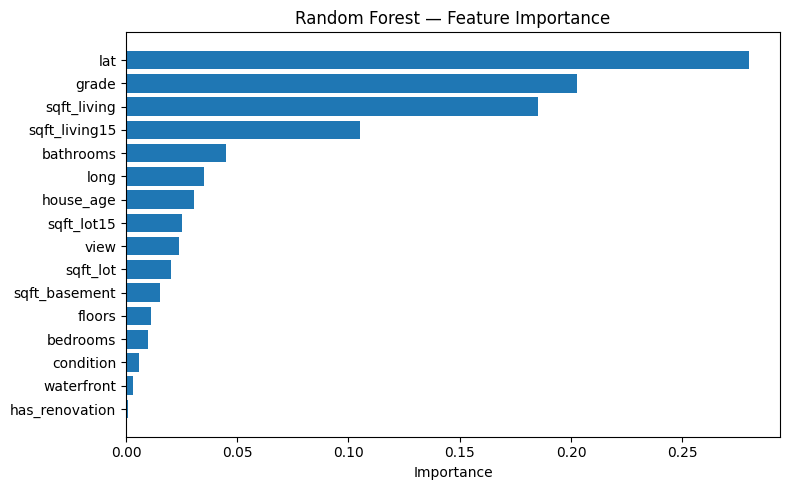

In [ ]:
# Feature importance — Random Forest
rf_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(rf_imp['Feature'], rf_imp['Importance'])
ax.set_xlabel('Importance')
ax.set_title('Random Forest — Feature Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

 ### Why not enough?
 Random Forest is strong but trains trees independently (bagging). Each tree tries to
 solve the full problem. Gradient boosting takes a different approach: each tree
 corrects the ERRORS of previous trees, often achieving better accuracy.

 ---
 ## Level 5: Gradient Boosting
 **Concept:** Train trees sequentially — each new tree focuses on the residual errors
 from all previous trees. Small learning rate + many trees = powerful ensemble.

 Using sklearn's HistGradientBoostingRegressor (inspired by LightGBM).

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb = HistGradientBoostingRegressor(
    max_iter=500,
    max_depth=8,
    learning_rate=0.05,
    min_samples_leaf=20,
    random_state=42,
)
hgb.fit(X_train, y_train)
y_pred_hgb = evaluate(hgb, 'Gradient Boosting (HGB)')


  Gradient Boosting (HGB)
  RMSE (log):   0.1641  (train: 0.1352)
  MAE:          $66,282
  R²:           0.9056
  MAPE:         12.0%


 ### Optional: XGBoost
 If you have xgboost installed (`pip install xgboost`), uncomment and run:

In [ ]:
try:
    import xgboost as xgb

    xgb_model = xgb.XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
    )
    xgb_model.fit(X_train, y_train)
    y_pred_xgb = evaluate(xgb_model, 'XGBoost')
except ImportError:
    print("XGBoost not installed. Run: pip install xgboost")
    print("Skipping — HistGradientBoosting results are comparable.")


  XGBoost
  RMSE (log):   0.1617  (train: 0.1140)
  MAE:          $64,514
  R²:           0.9082
  MAPE:         11.7%
  ⚠ Possible overfitting (train RMSE much lower than test)


 ---
 ## Level 6: Model Comparison

In [ ]:
comparison = pd.DataFrame(results)
comparison = comparison.sort_values('RMSE (log)')
print("\n" + "=" * 70)
print("  MODEL COMPARISON (sorted by RMSE)")
print("=" * 70)
print(comparison.to_string(index=False))


  MODEL COMPARISON (sorted by RMSE)
                   Model  RMSE (log)  Train RMSE       MAE ($)       R²  MAPE (%)
                 XGBoost    0.161721    0.113991  64514.455895 0.908243 11.712010
 Gradient Boosting (HGB)    0.164051    0.135176  66281.779768 0.905579 11.985779
           Random Forest    0.184993    0.137666  79005.298151 0.879934 13.510531
  Decision Tree (pruned)    0.218020    0.190625  94057.551765 0.833237 16.227232
Decision Tree (no limit)    0.248678    0.029116  99695.934475 0.783038 18.055001
        Ridge Regression    0.257327    0.252907 118048.252376 0.767685 20.252092
       Linear Regression    0.257332    0.252906 118071.155524 0.767675 20.253433
        Lasso Regression    0.257968    0.253414 118251.808463 0.766525 20.273534


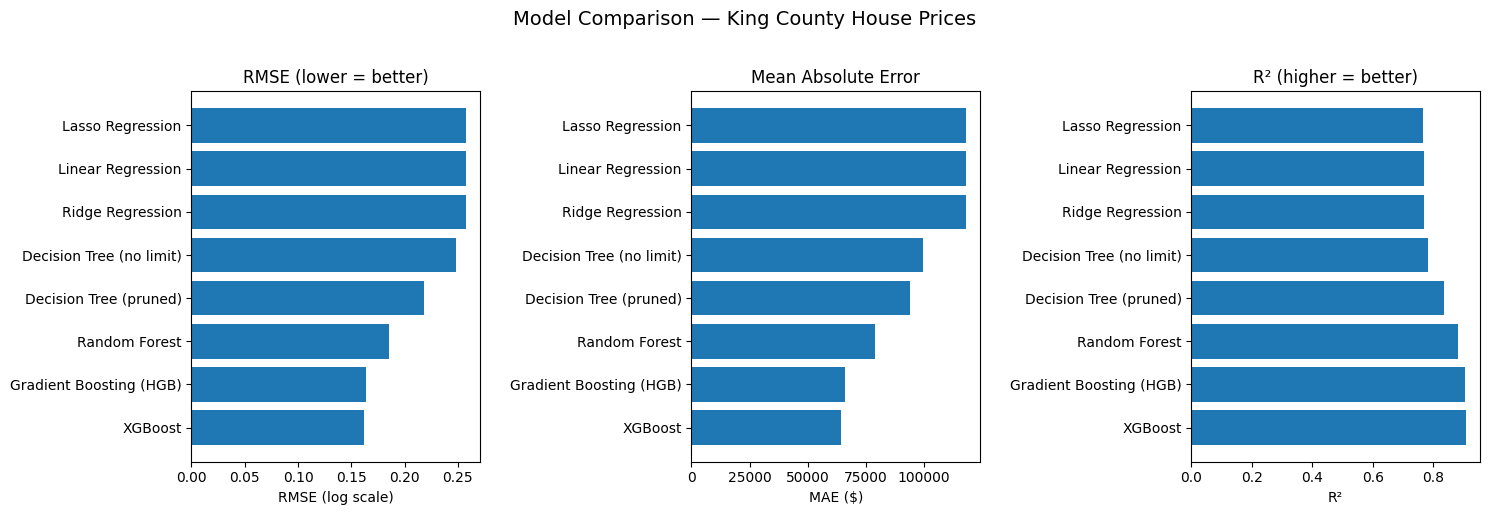

In [ ]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = comparison['Model']
x = range(len(models))

axes[0].barh(models, comparison['RMSE (log)'])
axes[0].set_xlabel('RMSE (log scale)')
axes[0].set_title('RMSE (lower = better)')

axes[1].barh(models, comparison['MAE ($)'])
axes[1].set_xlabel('MAE ($)')
axes[1].set_title('Mean Absolute Error')

axes[2].barh(models, comparison['R²'])
axes[2].set_xlabel('R²')
axes[2].set_title('R² (higher = better)')

plt.suptitle('Model Comparison — King County House Prices', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

 ## Residual Analysis — Best Model
 Check if the best model's errors are random or show patterns.

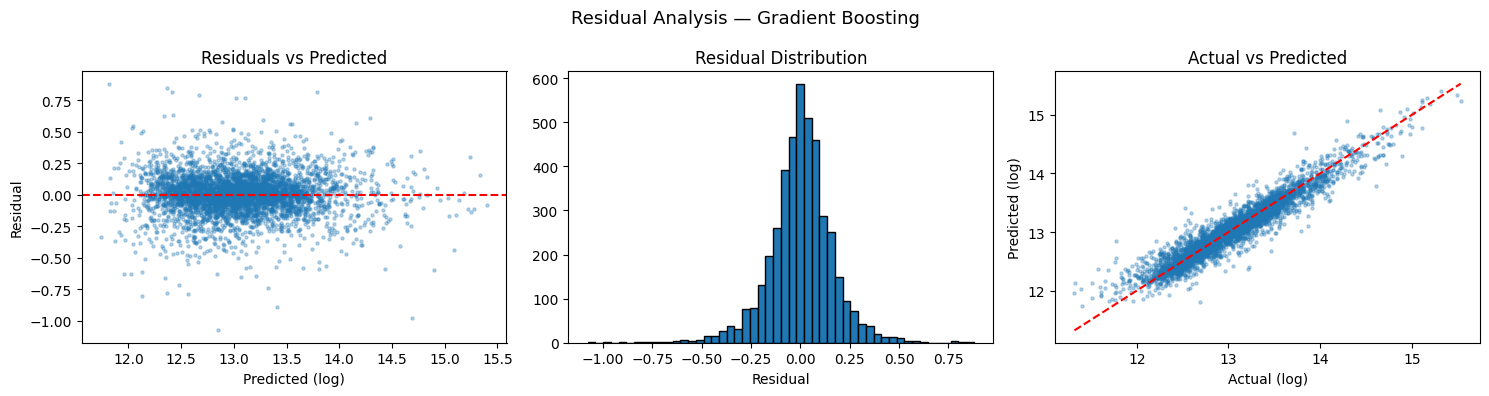

In [ ]:
# Use the best model's predictions (last gradient boosting)
best_pred = y_pred_hgb
residuals = y_test.values - best_pred

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuals vs predicted
axes[0].scatter(best_pred, residuals, alpha=0.3, s=5)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Predicted (log)')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted')

# Residual distribution
axes[1].hist(residuals, bins=50, edgecolor='black')
axes[1].set_xlabel('Residual')
axes[1].set_title('Residual Distribution')

# Actual vs predicted
axes[2].scatter(y_test, best_pred, alpha=0.3, s=5)
min_val = min(y_test.min(), best_pred.min())
max_val = max(y_test.max(), best_pred.max())
axes[2].plot([min_val, max_val], [min_val, max_val], 'r--')
axes[2].set_xlabel('Actual (log)')
axes[2].set_ylabel('Predicted (log)')
axes[2].set_title('Actual vs Predicted')

plt.suptitle('Residual Analysis — Gradient Boosting', fontsize=13)
plt.tight_layout()
plt.show()

 ## Summary

 | Level | Model | Key Takeaway |
 |-------|-------|-------------|
 | 1 | Linear Regression | Simple baseline, misses non-linear patterns |
 | 2 | Ridge/Lasso | Regularization helps little here (not many features) |
 | 3 | Decision Tree | Captures non-linearity but overfits or underfits |
 | 4 | Random Forest | Strong — averaging reduces variance |
 | 5 | Gradient Boosting | Best — sequential error correction |

 **Best model:** Gradient Boosting (check comparison table for exact metrics).

 -> Next: [07-evaluation](../07-evaluation/) for cross-validation, hyperparameter
    tuning, and final model selection.